In [1]:
# Test script 1

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from utils.utils import get_scenario_config, create_global_country_map

In [2]:
def load_regional_mortality_ensemble_members(model, scenario, config):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Regional_mortality_stats_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataset(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [3]:
def process_mortality_per_100k(ds):
    # === Path config ===
    POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

    pop_file = "ssp2_region_level_2000-2100.nc"
    pop_path = os.path.join(POP_DIR, pop_file)
    pop = xr.open_dataarray(pop_path)

    da = ds

    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last10 = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = da_last10.year[0].item()
    end_time = da_last10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_last10.mean(dim=("ensemble", "year"))

    # Calculate population mean
    years = slice(start_time, end_time)
    av_pop = pop.sel(year=years).mean("year")

    # Calculate mortality per 100,000
    da_per_100k = (da_mean/av_pop)*100000
    return da_per_100k, start_time, end_time

In [4]:
def process_stats_for_boxplot(ds, var_prefix="M"):
    """
    Build boxplot stats dictionaries for each region.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain variables: {prefix}_mean, {prefix}_median, {prefix}_25,
        {prefix}_75, {prefix}_lower95, {prefix}_upper95
        and coordinates 'year', 'ensemble', 'region'.
    var_prefix : str
        Prefix for variable names (default: "M").

    Returns
    -------
    stats_dict : dict
        Keys = region names, values = list with a single boxplot stats dict.
        This structure allows direct use with ax.bxp().
    regions : list
        List of region names (in the same order as stats_dict).
    """

    # build stats for each region
    stats_dict = {}
    for region in ds.region.values:
        reg = ds.sel(region=region)

        stats_dict[region] = [{
            "med": float(reg[f"{var_prefix}_median"].mean()),
            "mean": float(reg[f"{var_prefix}_mean"].mean()),
            "q1": float(reg[f"{var_prefix}_25"].mean()),
            "q3": float(reg[f"{var_prefix}_75"].mean()),
            "whislo": float(reg[f"{var_prefix}_lower95"].mean()),
            "whishi": float(reg[f"{var_prefix}_upper95"].mean()),
            "fliers": []
        }]

    return stats_dict, list(stats_dict.keys())

In [13]:
def sort_stats_dict(stats_dict):
    # Sort by mean values (descending order)
    region_means = {r: float(stats_dict[r][0]['mean']) for r in regions}
    sorted_regions = sorted(regions, key=lambda r: region_means[r], reverse=True)

    # Build ordered box_data list (bxp expects a dict per box)
    box_data = []
    for r in sorted_regions:
        st = dict(stats_dict[r][0])  # copy so we don't mutate original
        st['label'] = r  # optional, helpful for debugging
        box_data.append(st)
    return box_data

In [16]:
def plot_2_box_plot(ds1, ds2, model, scenario, SAVE_DIR):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Dataset A: SSP245, dataset B: G6-1.5K
    stats_A, regions = process_stats_for_boxplot(ds2)
    stats_B, regions = process_stats_for_boxplot(ds1)

    sorted_A = sort_stats_dict(stats_A)
    sorted_B = sort_stats_dict(stats_B)

    # x positions for each group
    x_A = np.arange(len(regions)) * 2.0  # space out decades
    x_B = x_A + 0.8  # offset for dataset B

    # Plot dataset A
    ax.bxp(
        sorted_A,
        positions=x_A,
        widths=0.6,
        showmeans=True,
        meanline=True,
        patch_artist=True,
        boxprops=dict(facecolor="skyblue"),
        medianprops=dict(color="darkred", linewidth=1),  # median line
        meanprops=dict(color="black", linewidth=1, ls="--")  # mean line
    )

    # Plot dataset B
    ax.bxp(sorted_B,
           positions=x_B,
           widths=0.6,
           showmeans=True,
           meanline=True,
           patch_artist=True,
           boxprops=dict(facecolor="lightcoral"),
           medianprops=dict(color="darkred", linewidth=1),  # median line
           meanprops=dict(color="black", linewidth=1, ls="--")  # mean line
    )

    # Custom x-ticks: center between the two
    xticks = (x_A + x_B) / 2
    ax.set_xticks(xticks)
    ax.set_xticklabels(regions)
    ax.set_ylim(bottom=0)

    ax.set_ylabel("Global Mortality")
    ax.legend([plt.Line2D([0], [0], color="skyblue", lw=4),
               plt.Line2D([0], [0], color="lightcoral", lw=4)],
              ["SSP245", "G6-1.5K"])

    plt.title("Global Mortality")

    out_file = f"Global_mortality_boxplot_{model}_{scenario}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    #plt.savefig(out_path)
    return

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


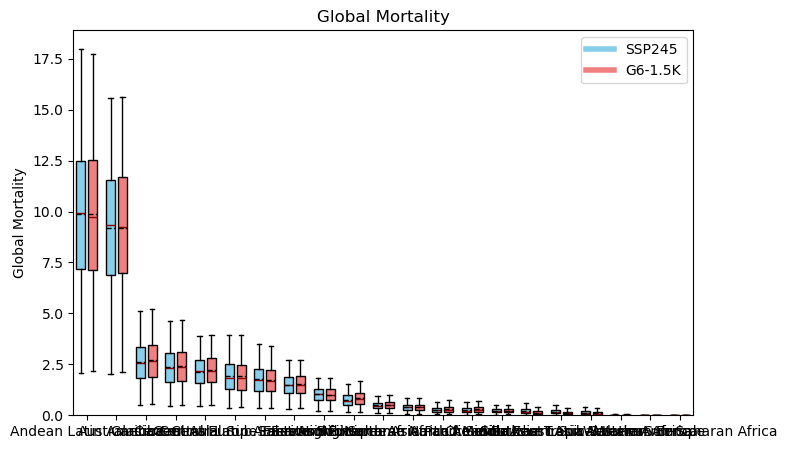

In [17]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "CESM2"
scenario = ["G6-1.5K", "SSP245_G6"]
scenario_name = f"{scenario[0]} - {scenario[1]}"  # Check this is the way round you want it

config1 = get_scenario_config(model, scenario[0])
config2 = get_scenario_config(model, scenario[1])

da1 = load_regional_mortality_ensemble_members(model, scenario[0], config1)
da2 = load_regional_mortality_ensemble_members(model, scenario[1], config2)

da1_per_100k, start_time, end_time = process_mortality_per_100k(da1)
da2_per_100k, start_time, end_time = process_mortality_per_100k(da2)

dates = f"{start_time}-{end_time}"

plot_2_box_plot(da1_per_100k, da2_per_100k, model, scenario_name, SAVE_DIR)

In [11]:
stats_A, regions = process_stats_for_boxplot(da2_per_100k)

In [12]:
stats_A

{'Andean Latin America': [{'med': 0.014648103814063413,
   'mean': 0.01998666728284779,
   'q1': 0.007055965588060772,
   'q3': 0.028297897416546744,
   'whislo': 0.0017892826487153459,
   'whishi': 0.06365528026033418,
   'fliers': []}],
 'Australasia': [{'med': 0.0003531025979959705,
   'mean': 0.0027294957356986775,
   'q1': 3.321469805008619e-05,
   'q3': 0.003406742436484727,
   'whislo': 6.759039942195375e-07,
   'whishi': 0.016490777323097387,
   'fliers': []}],
 'Caribbean': [{'med': 0.2261066903588927,
   'mean': 0.25962520893794766,
   'q1': 0.13789828765032522,
   'q3': 0.35191590411440543,
   'whislo': 0.037488446921491496,
   'whishi': 0.6396277592153324,
   'fliers': []}],
 'Central Asia': [{'med': 2.156243002409088,
   'mean': 2.1469113179512203,
   'q1': 1.5649782155508267,
   'q3': 2.716248165530468,
   'whislo': 0.4476292090334718,
   'whishi': 3.8947071088557847,
   'fliers': []}],
 'Central Europe': [{'med': 1.713600635561884,
   'mean': 1.7691403750517558,
   'q1':

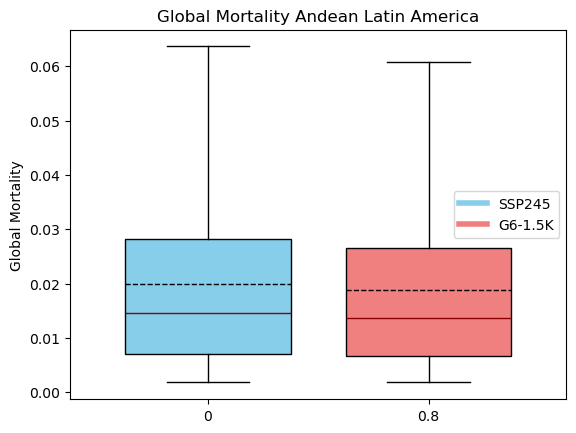

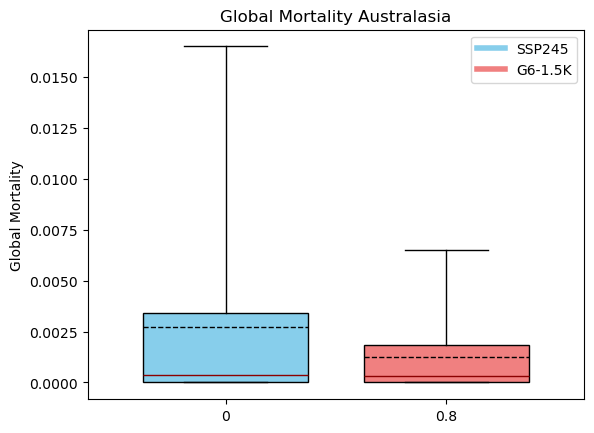

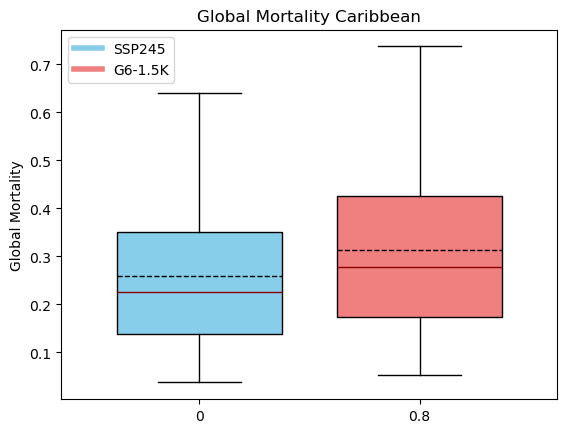

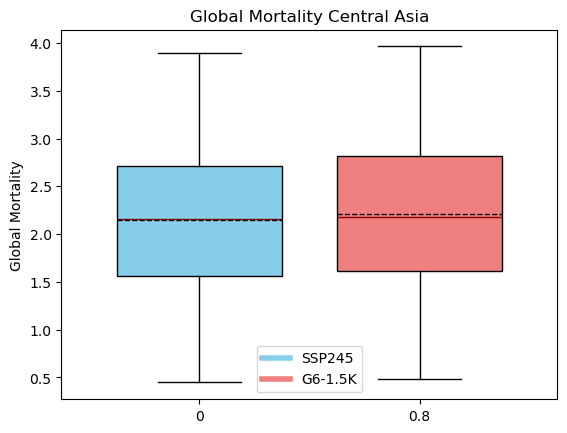

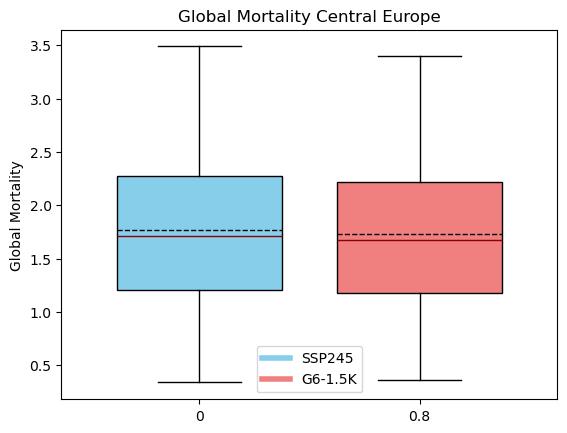

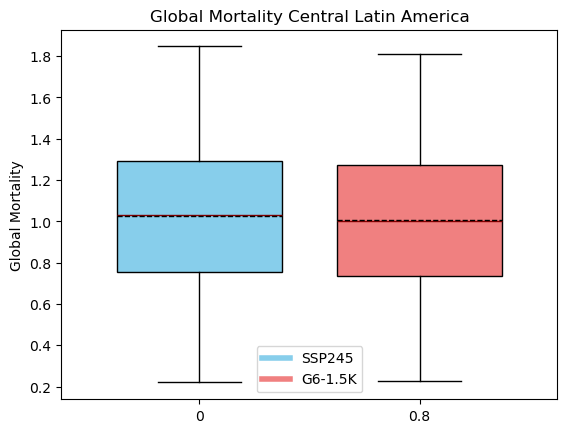

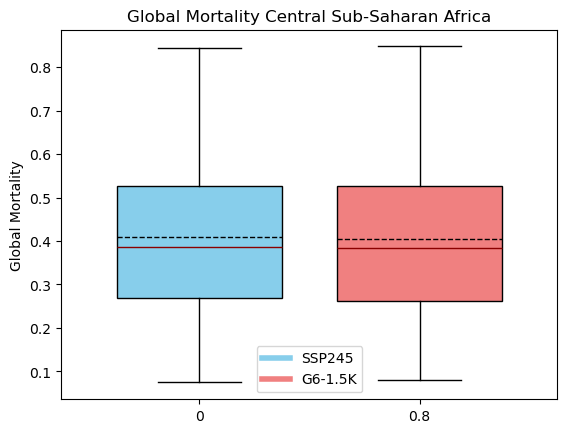

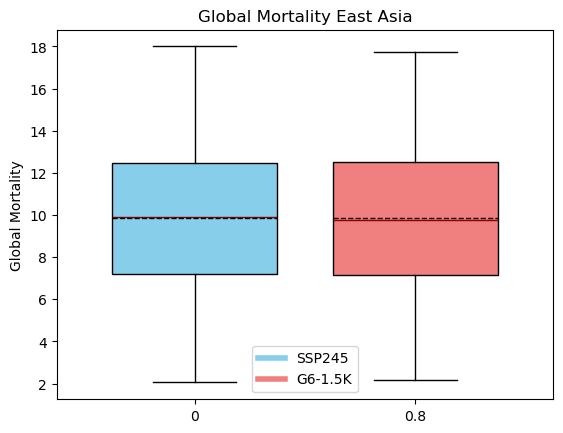

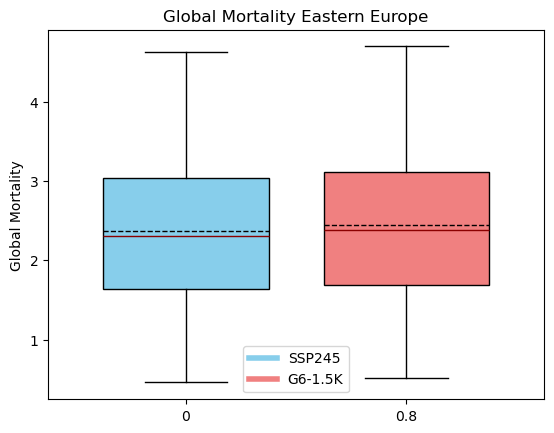

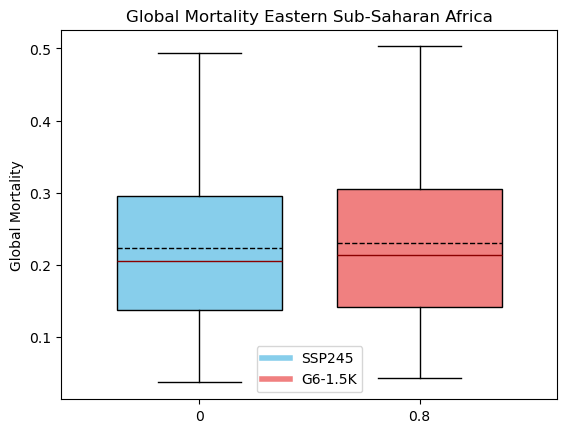

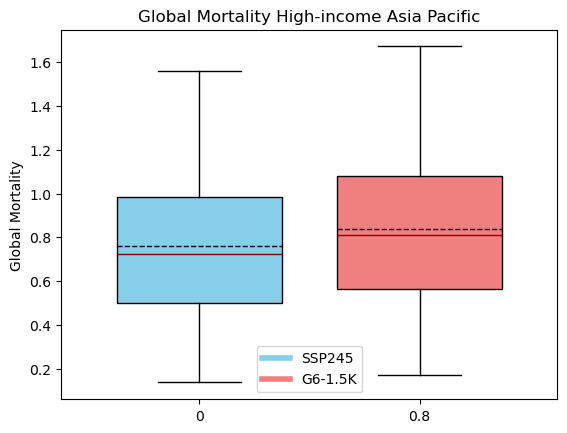

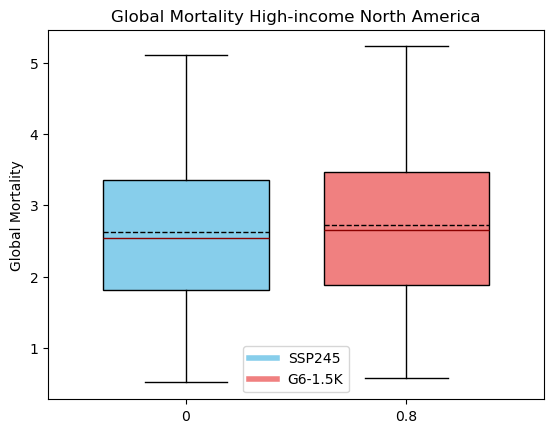

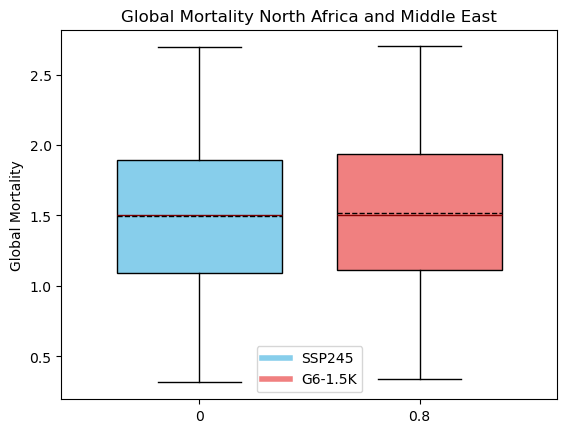

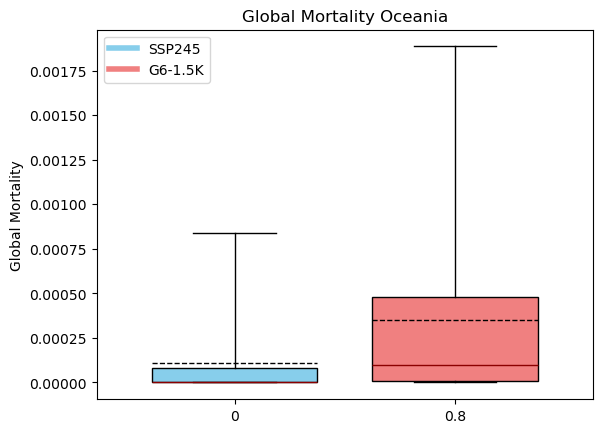

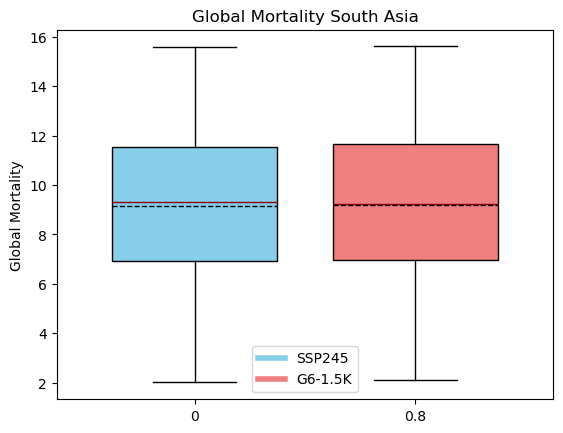

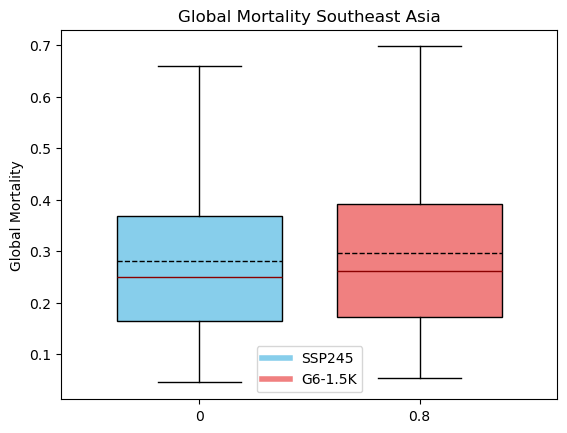

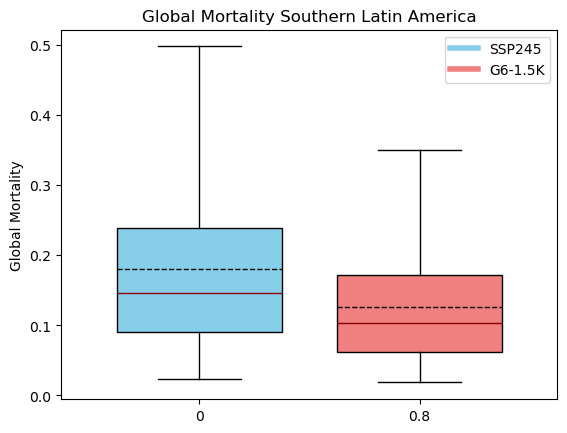

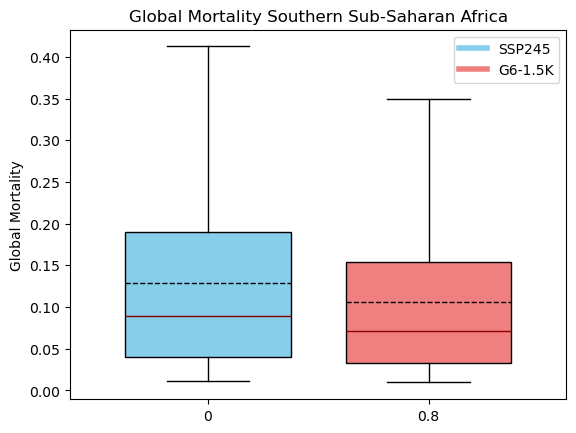

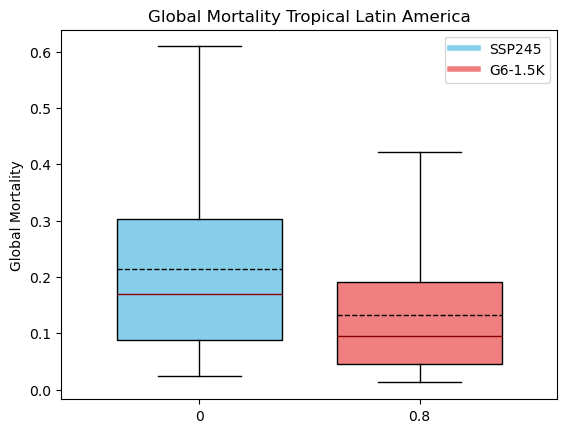

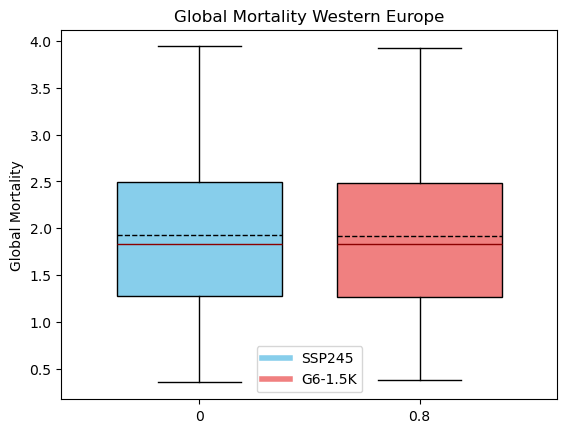

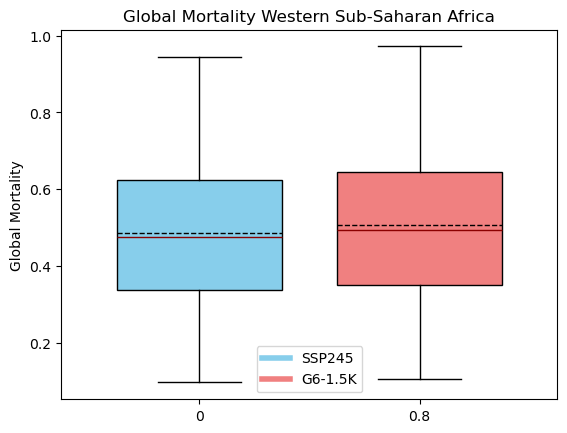

In [14]:
for region in da1.region:
    stats_B = create_stats(da1_per_100k.sel(region=region))
    stats_A = create_stats(da2_per_100k.sel(region=region))

    fig, ax = plt.subplots()

    # x positions for each group
    x_A = np.arange(1)  # space out decades
    x_B = x_A + 0.8  # offset for dataset B

    # Plot dataset A
    ax.bxp(
        stats_A,
        positions=x_A,
        widths=0.6,
        showmeans=True,
        meanline=True,
        patch_artist=True,
        boxprops=dict(facecolor="skyblue"),
        medianprops=dict(color="darkred", linewidth=1),  # median line
        meanprops=dict(color="black", linewidth=1, ls="--")  # mean line
    )

    # Plot dataset B
    ax.bxp(stats_B,
           positions=x_B,
           widths=0.6,
           showmeans=True,
           meanline=True,
           patch_artist=True,
           boxprops=dict(facecolor="lightcoral"),
           medianprops=dict(color="darkred", linewidth=1),  # median line
           meanprops=dict(color="black", linewidth=1, ls="--")  # mean line
    )

    ax.set_ylabel("Global Mortality")
    ax.legend([plt.Line2D([0], [0], color="skyblue", lw=4),
               plt.Line2D([0], [0], color="lightcoral", lw=4)],
              ["SSP245", "G6-1.5K"])

    plt.title(f"Global Mortality {region.data}")
    plt.show()